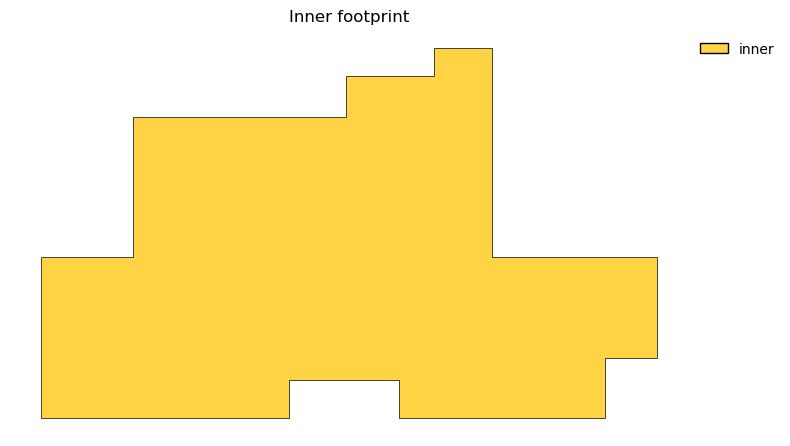

In [ ]:
import sys, pickle, matplotlib.pyplot as plt
sys.path.append('/mnt/data')

from resplan_utils import normalize_keys, plot_plan, CATEGORY_COLORS

# load a plan
with open('ResPlan.pkl','rb') as f:
    plans = pickle.load(f)

plan = normalize_keys(plans[0])

# plot only the inner polygon
colors = {**CATEGORY_COLORS, "inner": "#FFD344"}  # dark gray for inner
ax = plot_plan(
    {"inner": plan["inner"]},
    categories=["inner"],
    colors=colors,
    legend=True,
    title="Inner footprint"
)
plt.show()

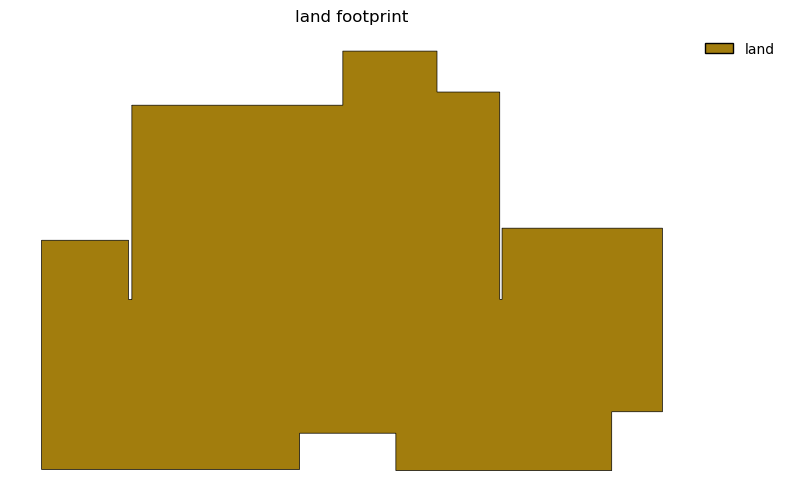

In [1]:
import sys, pickle, matplotlib.pyplot as plt
sys.path.append('/mnt/data')

from resplan_utils import normalize_keys, plot_plan, CATEGORY_COLORS

# load a plan
with open('ResPlan.pkl','rb') as f:
    plans = pickle.load(f)

plan = normalize_keys(plans[0])

# plot only the inner polygon
colors = {**CATEGORY_COLORS, "land": "#A27D0D"}  # dark gray for inner
ax = plot_plan(
    {"land": plan["land"]},
    categories=["land"],
    colors=colors,
    legend=True,
    title="land footprint"
)
plt.show()

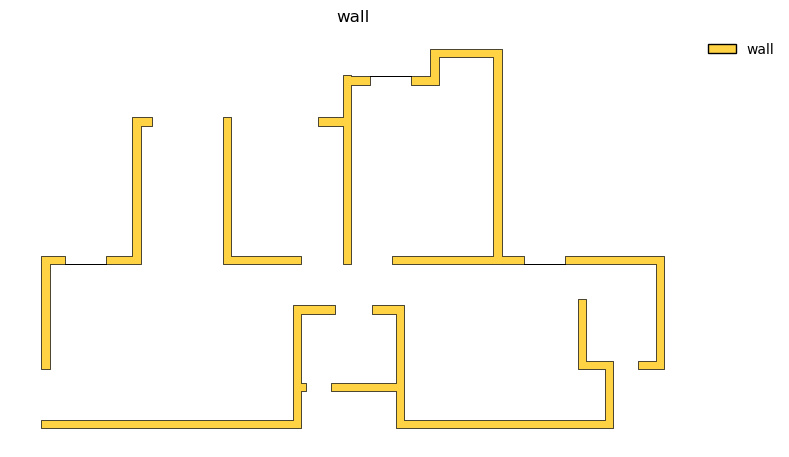

In [ ]:
import sys, pickle, matplotlib.pyplot as plt
sys.path.append('/mnt/data')

from resplan_utils import normalize_keys, plot_plan, CATEGORY_COLORS

# load a plan
with open('ResPlan.pkl','rb') as f:
    plans = pickle.load(f)

plan = normalize_keys(plans[0])

# plot only the wall
colors = {**CATEGORY_COLORS, "wall": "#FFD344"}  # dark gray for inner
ax = plot_plan(
    {"wall": plan["wall"]},
    categories=["wall"],
    colors=colors,
    legend=True,
    title="wall"
)
plt.show()

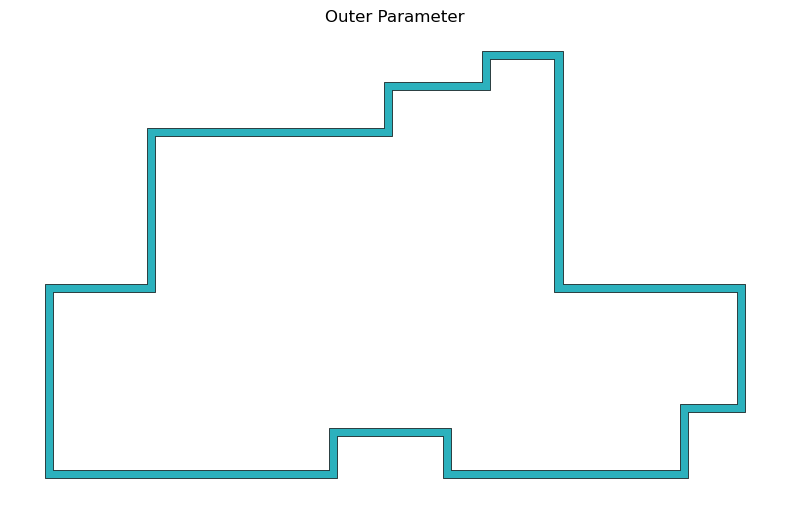

In [110]:
# build ring
p = normalize_keys(plan)
inner = p["inner"]
t = float(p.get("wall_width", 3) or 3)
inset = inner.buffer(+t, join_style=2, cap_style=2)
OuterParam = inset.difference(inner.buffer(0, join_style=2, cap_style=2))

# visualize ONLY the ring via plot_plan
ax = plot_plan(
    {"ring": OuterParam},             # put geometry under a key
    categories=["ring"],             # tell plot_plan to draw that key
    colors={"ring": "#2CB1BD"},      # facecolor for the band
    legend=False,
    title="Outer Parameter"
)

# If i want to keep a plan
#p["wall_ring"] = OuterParam

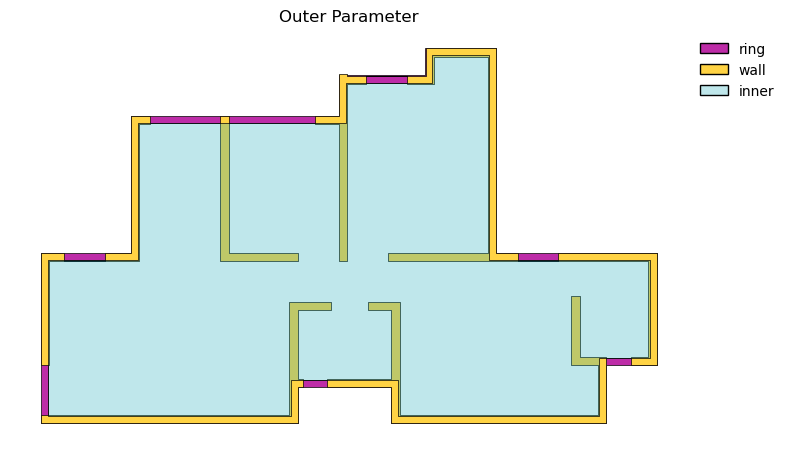

In [111]:
# check print all
from matplotlib.colors import to_rgba

ax = plot_plan(
    { "wall": plan["wall"], "inner": plan["inner"], "ring": OuterParam,},
    categories=["ring", "wall", "inner"],             
    colors={
        "ring": to_rgba("#BD2CA7", 1),   
        "wall": to_rgba("#FFD344", 1),
        "inner": to_rgba("#2CB1BD", 0.30),
    },      # facecolor for the band
    legend=True,
    title="Outer Parameter"
)

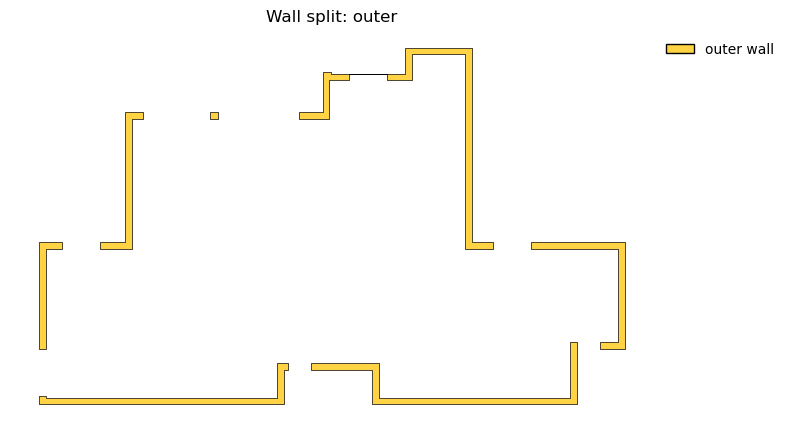

In [150]:
# Get the Exterior Wall via substraction

import sys, pickle
sys.path.append('/mnt/data')

from shapely.geometry import Polygon, MultiPolygon, LineString, MultiLineString
from shapely.ops import unary_union
from resplan_utils import normalize_keys, plot_plan, get_geometries, get_plan_width

# --- load / prep ---
with open('ResPlan.pkl','rb') as f:
    plans = pickle.load(f)
plan = normalize_keys(plans[0])

# walls
walls = plan["wall"]

# outer parameter ring
p = normalize_keys(plan)
inner = p["inner"]

# substraction with difference
outer_wall= walls.difference(inner) # left with outer wall only

# visualize
ax = plot_plan(
    { "outer_wall": outer_wall},
    categories=["outer_wall"],
    colors={"outer_wall": "#FFD344"},
    legend=True,
    title="Wall split: outer"
)

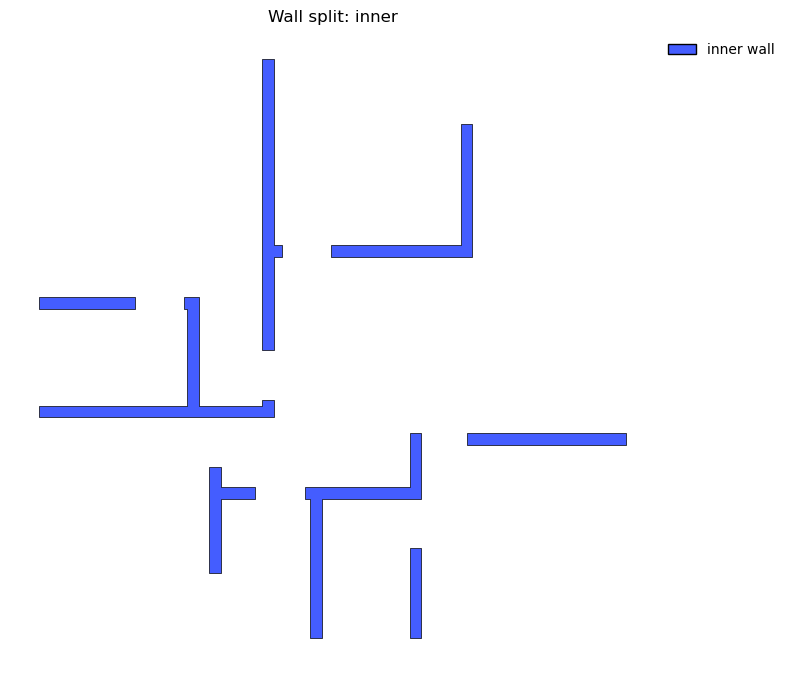

In [ ]:
# Get the Interior Wall via substraction

import sys, pickle
sys.path.append('/mnt/data')

from shapely.geometry import Polygon, MultiPolygon, LineString, MultiLineString
from shapely.ops import unary_union
from resplan_utils import normalize_keys, plot_plan, get_geometries, get_plan_width

# --- load / prep ---
with open('ResPlan.pkl','rb') as f:
    plans = pickle.load(f)
plan = normalize_keys(plans[0])

# walls
walls = plan["wall"]

# outer parameter ring
p = normalize_keys(plan)
t = float(p.get("wall_width", 1) or 1)
inner = p["inner"]
inset = inner.buffer(-t, join_style=2, cap_style=2)

# substraction with difference
inner_wall= walls.intersection(inset) # left with inner wall only

# visualize
ax = plot_plan(
    { "inner_wall": inner_wall},
    categories=["inner_wall"],
    colors={"inner_wall": "#445DFF"},
    legend=True,
    title="Wall split: inner"
)

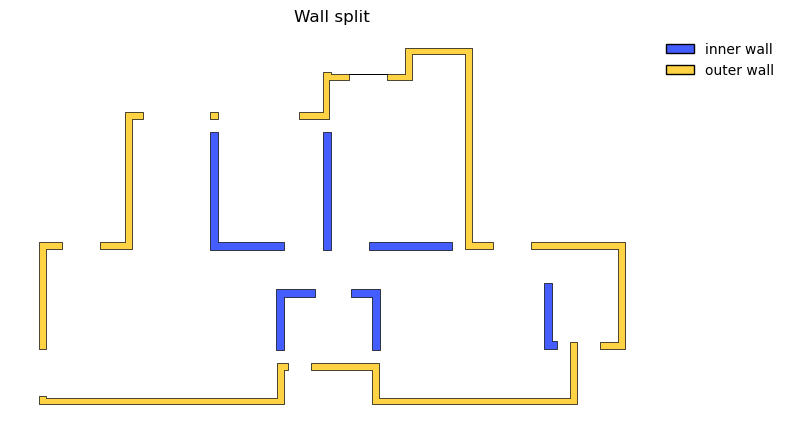

In [151]:

# visualize
ax = plot_plan(
    { "outer_wall": outer_wall, "inner_wall": inner_wall},
    categories=["inner_wall", "outer_wall"],
    colors={"inner_wall": "#445DFF", "outer_wall": "#FFD344"},
    legend=True,
    title="Wall split"
)

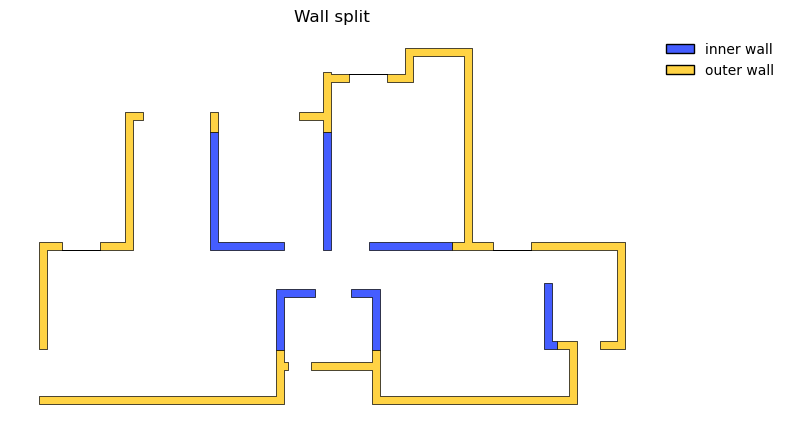

In [ ]:
# Alternative approach: band via buffer, then split walls via intersection/difference
import sys, pickle
sys.path.append('/mnt/data')

from shapely.geometry import Polygon, MultiPolygon, LineString, MultiLineString
from shapely.ops import unary_union
from resplan_utils import normalize_keys, plot_plan, get_geometries, get_plan_width

# walls → solid polygons (works whether walls are lines or polys)
def wall_as_polygons(plan, fallback_frac=0.01):
    W = get_plan_width(plan) or 1.0
    bufw = fallback_frac * W
    polys = []
    for g in get_geometries(plan.get("wall")):
        if isinstance(g, (Polygon, MultiPolygon)):
            polys += [g] if isinstance(g, Polygon) else list(g.geoms)
        else:  # LineString / MultiLineString
            polys.append(g.buffer(bufw, join_style=2, cap_style=2))
    return unary_union(polys).buffer(0)

# --- load ---
with open('ResPlan.pkl','rb') as f:
    plans = pickle.load(f)
plan  = normalize_keys(plans[0])
inner = plan["inner"]
walls = wall_as_polygons(plan)

# one mask only: boundary band
W = get_plan_width(plan) or 1.0
t = float(plan.get("wall_width", 4) or 4)
band_halfwidth = 1.5 * t  # broaden a bit to tolerate doors/offsets
boundary_band = inner.boundary.buffer(band_halfwidth, join_style=2, cap_style=2) # band around inner

# complementary split (covers all; no gap)
outer_wall = walls.intersection(boundary_band)     # near perimeter
inner_wall = walls.difference(boundary_band)       # everything else

# visualize
ax = plot_plan(
    {"inner_wall": inner_wall, "outer_wall": outer_wall},
    categories=["inner_wall","outer_wall"],
    colors={"inner_wall":"#445DFF","outer_wall":"#FFD344"},
    legend=True,
    title="Wall split"
)

/var/folders/_r/pq1zmsn93blcqytv44mnlsrm0000gn/T/ipykernel_2696/2364434753.py:160: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("tab20", max(1,len(insts)))


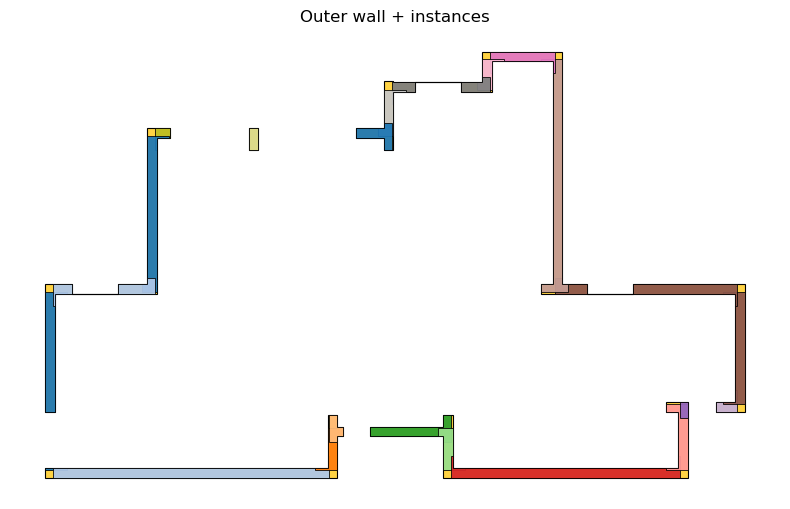

In [ ]:
# import sys, pickle
# sys.path.append('/mnt/data')

# import math
# import matplotlib.pyplot as plt
# from matplotlib import cm
# from shapely.geometry import Polygon, MultiPolygon, LineString, MultiLineString, GeometryCollection
# from shapely.ops import unary_union
# from resplan_utils import normalize_keys, get_geometries, get_plan_width

# # --- walls → solid polygons (works whether walls are lines or polys)
# def walls_as_polygons(plan, fallback_frac=0.006):
#     W = get_plan_width(plan) or 1.0
#     bufw = fallback_frac * W
#     polys = []
#     for g in get_geometries(plan.get("wall")):
#         if isinstance(g, (Polygon, MultiPolygon)):
#             polys += [g] if isinstance(g, Polygon) else list(g.geoms)
#         else:  # LineString/MultiLineString
#             polys.append(g.buffer(bufw, cap_style=2, join_style=2))
#     return unary_union(polys).buffer(0)

# def poly_parts(geom):
#     if geom is None or geom.is_empty: return []
#     if isinstance(geom, Polygon): return [geom]
#     if isinstance(geom, MultiPolygon): return list(geom.geoms)
#     if isinstance(geom, GeometryCollection):
#         out=[]
#         for g in geom.geoms: out += poly_parts(g)
#         return out
#     return []

# # --- clean footprint and edges
# def largest_polygon(g):
#     return max(g.geoms, key=lambda p: p.area) if isinstance(g, MultiPolygon) else g

# def inner_edges(poly):
#     cs = list(poly.exterior.coords)
#     return [LineString([cs[i], cs[i+1]]) for i in range(len(cs)-1) if cs[i]!=cs[i+1]]

# # --- build outer-wall instances
# def build_outer_wall_and_instances(plan, *,
#     t=None,                   # float | None  (default: plan["wall_width"] or 4.0)
#     band_factor=1.5,          # perimeter band half-width = band_factor * t
#     band_min_frac=0.02,       # fallback half-width if band_factor*t is too small: band_min_frac * W
#     fallback_frac=0.006,      # line→polygon buffer thickness (× W)
#     simplify_frac=0.003,      # footprint simplify tolerance (× W)
#     min_area_frac=1e-8,       # minimum polygon area (× W × W)
#     join_style=2, cap_style=2,
#     order_clockwise=True
# ):
#     p = normalize_keys(plan)
#     inner = p["inner"];  inner = max(inner.geoms, key=lambda g: g.area) if inner.geom_type=="MultiPolygon" else inner
#     W = get_plan_width(p) or 1.0
#     t = float(p.get("wall_width", 4.0) if t is None else t)
#     band_hw = max(band_factor * t, band_min_frac * W)

#     # walls→polygons
#     def walls_as_polygons():
#         bufw = fallback_frac * W
#         polys=[]
#         for g in get_geometries(p.get("wall")):
#             if isinstance(g, (Polygon, MultiPolygon)):
#                 polys += [g] if isinstance(g, Polygon) else list(g.geoms)
#             else:
#                 polys.append(g.buffer(bufw, cap_style=cap_style, join_style=join_style))
#         return unary_union(polys).buffer(0)

#     def poly_parts(g):
#         if g is None or g.is_empty: return []
#         if isinstance(g, Polygon): return [g]
#         if isinstance(g, MultiPolygon): return list(g.geoms)
#         if isinstance(g, GeometryCollection):
#             out=[];  [out.extend(poly_parts(h)) for h in g.geoms];  return out
#         return []

#     def inner_edges(poly):
#         cs = list(poly.exterior.coords)
#         return [LineString([cs[i], cs[i+1]]) for i in range(len(cs)-1) if cs[i]!=cs[i+1]]

#     inner_s = inner.simplify(simplify_frac * W, preserve_topology=True)
#     walls_poly = walls_as_polygons()
#     outer_mask = inner.boundary.buffer(band_hw, cap_style=cap_style, join_style=join_style)
#     outer_wall = walls_poly.intersection(outer_mask).buffer(0)

#     # edge tubes → clip to outer_wall
#     instances = []
#     for e in inner_edges(inner_s):
#         tube   = e.buffer(band_hw, cap_style=cap_style, join_style=join_style)
#         piece  = unary_union(poly_parts(tube.intersection(outer_wall).buffer(0)))
#         for g in poly_parts(piece):
#             if g.area >= (min_area_frac * W * W):
#                 instances.append((e, g))

#     if order_clockwise:
#         cx, cy = inner.centroid.x, inner.centroid.y
#         def ang(e): m = e.interpolate(0.5, normalized=True); return math.atan2(m.y-cy, m.x-cx)
#         instances.sort(key=lambda eg: ang(eg[0]))

#     return {
#         "outer_wall": outer_wall,                 # Polygon/MultiPolygon
#         "instances":  [g for _, g in instances],  # list[Polygon] in order
#         "inner":      inner,
#         "params":     dict(t=t, band_factor=band_factor, band_min_frac=band_min_frac,
#                            fallback_frac=fallback_frac, simplify_frac=simplify_frac,
#                            min_area_frac=min_area_frac, join_style=join_style,
#                            cap_style=cap_style, order_clockwise=order_clockwise)
#     }

# # --- visualize with distinct colors and ordered labels
# def plot_instances(insts, inner, title):
#     fig, ax = plt.subplots(figsize=(8,8))
#     ax.set_aspect("equal"); ax.axis("off"); ax.set_title(title)
#     # outline only
#     x,y = inner.exterior.xy
#     ax.plot(x, y, color="black", linewidth=1.0)

#     n = max(1, len(insts))
#     cmap = cm.get_cmap("tab20", n)
#     for i, p in enumerate(insts, start=1):
#         x,y = p.exterior.xy
#         ax.fill(x, y, facecolor=cmap((i-1) % 20), edgecolor="black", linewidth=0.6, alpha=0.95)
#         c = p.representative_point()
#         ax.text(c.x, c.y, f"{i}", fontsize=7)
#     plt.tight_layout(); plt.show()

# # --- LOAD PLAN ---
# import sys, pickle
# sys.path.append('/mnt/data')
# with open('ResPlan.pkl','rb') as f:
#     plans = pickle.load(f)
# plan = normalize_keys(plans[0])

# # --- BUILD + PLOT ---
# cfg = dict(
#     t=None,                # use plan["wall_width"]
#     band_factor=1,
#     band_min_frac=0.02,
#     fallback_frac=0.005,
#     simplify_frac=0.0025,
#     min_area_frac=5e-8,
#     join_style=2, cap_style=2, order_clockwise=True
# )

# out = build_outer_wall_and_instances(plan, **cfg)
# outer_wall, insts, inner = out["outer_wall"], out["instances"], out["inner"]

# import matplotlib.pyplot as plt
# from matplotlib import cm
# fig, ax = plt.subplots(figsize=(8,8))
# ax.set_aspect("equal"); ax.axis("off"); ax.set_title("Outer wall + instances")

# # yellow background
# parts = list(outer_wall.geoms) if hasattr(outer_wall,"geoms") else [outer_wall]
# for g in parts:
#     x,y = g.exterior.xy
#     ax.fill(x, y, facecolor="#FFD344", edgecolor="black", linewidth=0.8)

# # instances overlay
# cmap = cm.get_cmap("tab20", max(1,len(insts)))
# for i,p in enumerate(insts, start=1):
#     x,y = p.exterior.xy
#     ax.fill(x, y, facecolor=cmap((i-1)%20), edgecolor="black", linewidth=0.6, alpha=0.95)

# # # optional: inner outline
# # xi, yi = inner.exterior.xy
# # ax.plot(xi, yi, color="black", linewidth=1.0)

# plt.tight_layout(); plt.show()

Exterior instances: 5
  outer_wall_1: area=1033.42, perim=670.24
  outer_wall_2: area=604.77, perim=346.52
  outer_wall_3: area=471.20, perim=271.56
  outer_wall_4: area=31.97, perim=25.07
  outer_wall_5: area=469.93, perim=312.43
Interior instances: 6
  inner_wall_1: area=132.08, perim=81.25
  inner_wall_2: area=188.18, perim=112.73
  inner_wall_3: area=113.03, perim=70.56
  inner_wall_4: area=132.08, perim=81.25
  inner_wall_5: area=147.96, perim=90.16
  inner_wall_6: area=292.96, perim=171.54


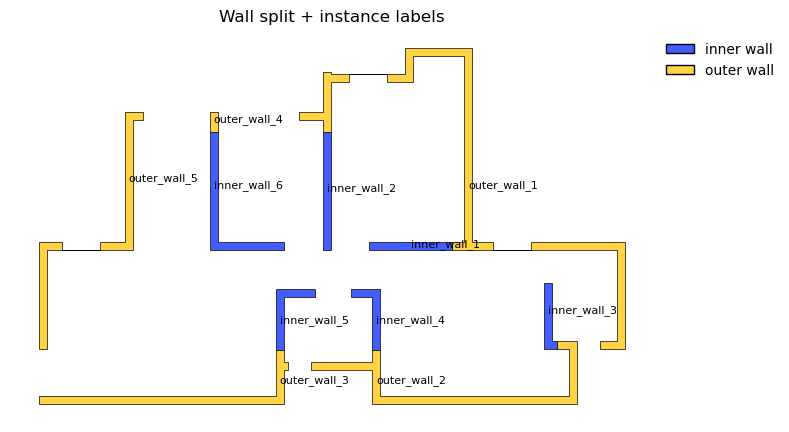

In [177]:
import sys, pickle
sys.path.append('/mnt/data')

import matplotlib.pyplot as plt
from shapely.geometry import Polygon, MultiPolygon, LineString, MultiLineString
from shapely.ops import unary_union
from resplan_utils import normalize_keys, plot_plan, get_geometries, get_plan_width

# 1) Walls → solid polygons (handles line-based walls too)
def wall_as_polygons(plan, fallback_frac=0.01):
    W = get_plan_width(plan) or 1.0
    bufw = fallback_frac * W
    polys = []
    for g in get_geometries(plan.get("wall")):
        if isinstance(g, (Polygon, MultiPolygon)):
            polys += [g] if isinstance(g, Polygon) else list(g.geoms)
        else:  # LineString / MultiLineString
            polys.append(g.buffer(bufw, join_style=2, cap_style=2))
    return unary_union(polys).buffer(0)

# 2) Generic instance builder (correct labels)
def make_instances(geom, prefix):
    inst = []
    if geom.is_empty:
        return inst
    if isinstance(geom, MultiPolygon):
        for i, poly in enumerate(geom.geoms, 1):
            inst.append({"id": f"{prefix}_{i}", "geometry": poly,
                         "area": poly.area, "perimeter": poly.length})
    else:  # Polygon
        inst.append({"id": f"{prefix}_1", "geometry": geom,
                     "area": geom.area, "perimeter": geom.length})
    return inst

# --- load + split with one perimeter band ---
with open('ResPlan.pkl','rb') as f:
    plans = pickle.load(f)
plan  = normalize_keys(plans[0])

inner = plan["inner"]
walls = wall_as_polygons(plan)

W = get_plan_width(plan) or 1.0
t = float(plan.get("wall_width", 4) or 4)
band_halfwidth = 1.5 * t
boundary_band = inner.boundary.buffer(band_halfwidth, join_style=2, cap_style=2)

outer_wall = walls.intersection(boundary_band)     # yellow
inner_wall = walls.difference(boundary_band)       # blue

# Instances with correct prefixes
exterior_instances = make_instances(outer_wall,  "outer_wall")
interior_instances = make_instances(inner_wall,  "inner_wall")

# ---- Print a concise inventory ----
print("Exterior instances:", len(exterior_instances))
for it in exterior_instances:
    print(f"  {it['id']}: area={it['area']:.2f}, perim={it['perimeter']:.2f}")
print("Interior instances:", len(interior_instances))
for it in interior_instances:
    print(f"  {it['id']}: area={it['area']:.2f}, perim={it['perimeter']:.2f}")

# ---- Plot in the 'Wall split' style, with labels on instances ----
ax = plot_plan(
    {"inner_wall": inner_wall, "outer_wall": outer_wall},
    categories=["inner_wall", "outer_wall"],
    colors={"inner_wall": "#445DFF", "outer_wall": "#FFD344"},
    legend=True,
    title="Wall split + instance labels"
)

# Label exterior pieces
for it in exterior_instances:
    c = it["geometry"].representative_point()
    ax.text(c.x, c.y, it["id"], fontsize=8, color="black")

# Label interior pieces
for it in interior_instances:
    c = it["geometry"].representative_point()
    ax.text(c.x, c.y, it["id"], fontsize=8, color="black")

plt.tight_layout(); plt.show()

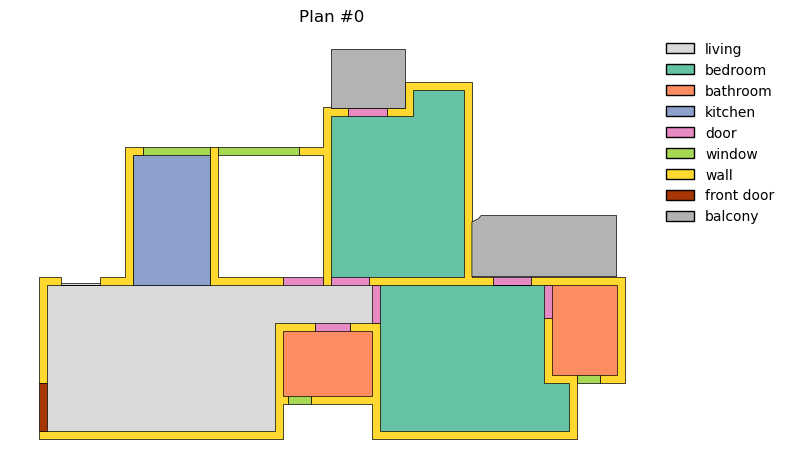

In [178]:

plan  = normalize_keys(plans[0])
ax = plot_plan(plan, title=f'Plan #{0}')
plt.show()

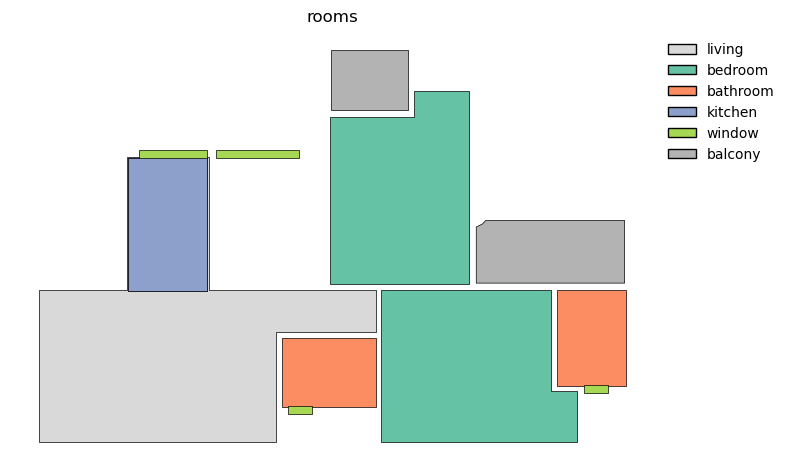

In [2]:
import sys, pathlib
repo_root = pathlib.Path("/Users/muhammadnumanmuttaqi/Documents/MScITBE/Thesis/Thesis/Geometry-to-Ontology")
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import sys, pickle, matplotlib.pyplot as plt
sys.path.append('/mnt/data')

from resplan_utils import normalize_keys, plot_plan, CATEGORY_COLORS

# load a plan
with open('../data/ResPlan.pkl','rb') as f:
    plans = pickle.load(f)

plan = normalize_keys(plans[0])

# plot only the rooms
colors = {**CATEGORY_COLORS}  
ax = plot_plan(
    {"window": plan["window"],
    "living": plan["living"],
     "bedroom": plan["bedroom"],
    "bathroom": plan["bathroom"],
    "kitchen": plan["kitchen"],
    "balcony": plan["balcony"]},
    colors=colors,
    legend=True,
    title="rooms"
)
plt.show()
